# Google Ads Campaign Simulation & Performance Optimization

In this project, we explore a dataset simulating marketing campaign performance across various channels including social, search, media, and influencer campaigns. Using key performance metrics such as impressions, clicks, spend, conversions, and revenue, we calculate and visualize the effectiveness of each campaign.

The goal is to:
- Simulate a Google Ads style analysis
- Identify high and low performing campaigns
- Calculate KPIs like CTR, CPC, Conversion Rate, and ROAS
- Recommend optimization strategies for better ad spend efficiency

This type of analysis is critical for marketing professionals aiming to maximize the return on advertising investment (ROAS) and improve digital performance.


# Section 1 - Load and Preview Data
We begin by loading the marketing dataset, which includes information on campaign performance such as impressions, clicks, spend, leads, orders, and revenue. This gives us a foundation for calculating meaningful advertising KPIs.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/analyze-the-marketing-spending/Marketing.csv')
df.head()

,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0


## Section 2 - Calculating Key Performance indicators

In this step, we calculate important Google Ads KPIs including Click-Through Rate (CTR), Cost Per Click (CPC), Cost Per Lead, Conversion Rate, and Return on Ad Spend (ROAS). These help us measure the efficiency and profitability of each campaign.

In [3]:
df['CTR'] = df['clicks'] / df['impressions']
df['CPC'] = df['mark_spent'] / df['clicks']
df['Cost_per_Lead'] = df['mark_spent'] / df['leads']
df['Conversion_Rate'] = df['orders'] / df['clicks']
df['ROAS'] = df['revenue'] / df['mark_spent']

## Section 3 - Summarizing Campaign-Level Performance

To get a clearer view of how each campaign is performing, we aggregate the data by campaign name and re-calculate all KPIs. This allows us to compare performance across campaigns and spot trends in cost efficiency and conversion effectiveness.

In [4]:
campaign_summary = df.groupby('campaign_name').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'mark_spent': 'sum',
    'leads': 'sum',
    'orders': 'sum',
    'revenue': 'sum'
}).reset_index()

# Recalculate KPIs for the group
campaign_summary['CTR'] = campaign_summary['clicks'] / campaign_summary['impressions']
campaign_summary['CPC'] = campaign_summary['mark_spent'] / campaign_summary['clicks']
campaign_summary['Conversion_Rate'] = campaign_summary['orders'] / campaign_summary['clicks']
campaign_summary['ROAS'] = campaign_summary['revenue'] / campaign_summary['mark_spent']
campaign_summary

,campaign_name,impressions,clicks,mark_spent,leads,orders,revenue,CTR,CPC,Conversion_Rate,ROAS
0,banner_partner,1068337427,420003,5026674.76,10149,1566,6152960.0,0.000393,11.968188,0.003729,1.224062
1,facebOOK_tier2,69623161,329973,4693870.97,8428,688,3463306.0,0.004739,14.225015,0.002085,0.737836
2,facebook_lal,12697701,120012,2641939.24,1909,294,300233.0,0.009451,22.013959,0.002450,0.113641
3,facebook_retargeting,976685,29954,266466.22,506,108,536919.0,0.030669,8.895848,0.003606,2.014961
4,facebook_tier1,63044882,239997,2564793.48,3535,474,2396412.0,0.003807,10.686773,0.001975,0.934349
5,google_hot,4628993,90048,1199998.76,1833,281,2205747.0,0.019453,13.326212,0.003121,1.838124
6,google_wide,67669259,240006,2260401.31,5274,547,1499318.0,0.003547,9.418103,0.002279,0.663297
7,instagram_blogger,34112411,299959,4247367.57,7008,1100,5808454.0,0.008793,14.159827,0.003667,1.367542
8,instagram_tier1,75136799,269961,2565277.25,6632,758,4544124.0,0.003593,9.502399,0.002808,1.771397
9,instagram_tier2,137806768,509992,1066153.75,10374,313,670460.0,0.003701,2.090530,0.000614,0.628859


## Section 4 - Visualizing Top Campaigns by ROAS and CTR

We use bar charts to highlight the best and worst performing campaigns based on key metrics like ROAS and CTR. These visuals help quickly identify which campaigns are driving the most value and which ones may require closer scrutiny.

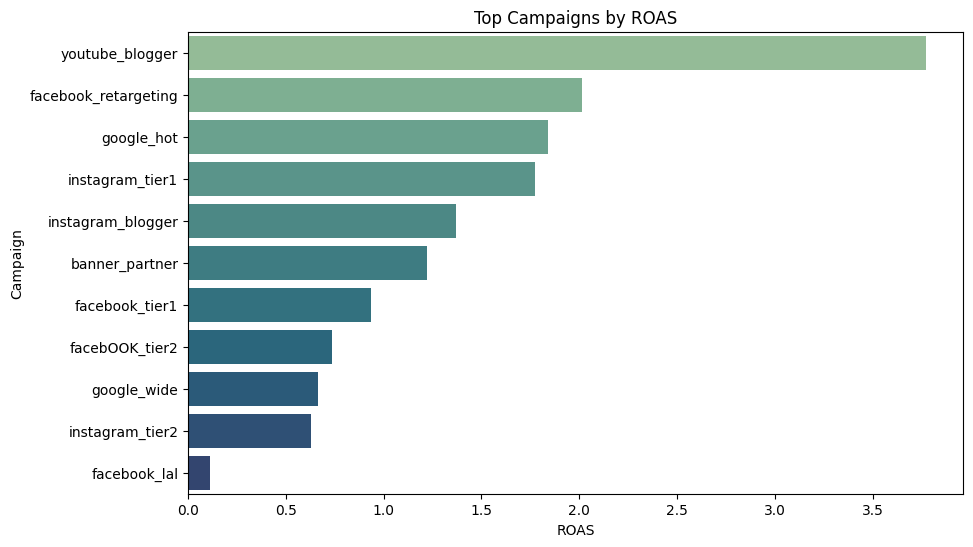

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=campaign_summary.sort_values('ROAS', ascending=False), x='ROAS', y='campaign_name', palette='crest')
plt.title('Top Campaigns by ROAS')
plt.xlabel('ROAS')
plt.ylabel('Campaign')
plt.show()

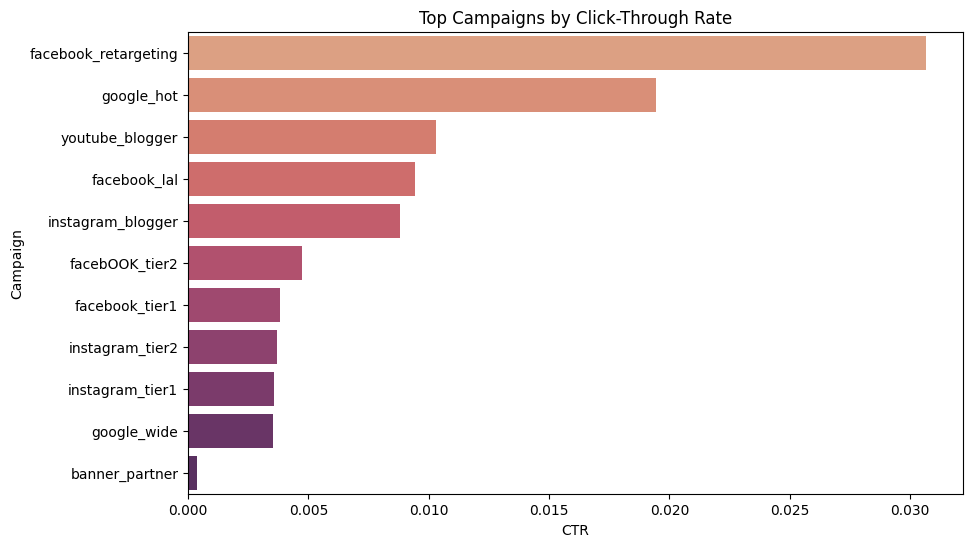

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=campaign_summary.sort_values('CTR', ascending=False), x='CTR', y='campaign_name', palette='flare')
plt.title('Top Campaigns by Click-Through Rate')
plt.xlabel('CTR')
plt.ylabel('Campaign')
plt.show()

## Section 5 - Performance Classifacation 

Here, we categorize each campaign into performance tiers: High Performer, Average, or Needs Optimization. This helps prioritize next steps and guides decisions on budget allocation and campaign improvement.

In [7]:
# Flag high-performing and underperforming campaigns
def performance_tag(row):
    if row['ROAS'] > 1.5 and row['CTR'] > 0.05:
        return 'High Performer'
    elif row['ROAS'] < 1.0:
        return 'Needs Optimization'
    else:
        return 'Average'

campaign_summary['Performance'] = campaign_summary.apply(performance_tag, axis=1)
campaign_summary[['campaign_name', 'ROAS', 'CTR', 'Performance']]

,campaign_name,ROAS,CTR,Performance
0,banner_partner,1.224062,0.000393,Average
1,facebOOK_tier2,0.737836,0.004739,Needs Optimization
2,facebook_lal,0.113641,0.009451,Needs Optimization
3,facebook_retargeting,2.014961,0.030669,Average
4,facebook_tier1,0.934349,0.003807,Needs Optimization
5,google_hot,1.838124,0.019453,Average
6,google_wide,0.663297,0.003547,Needs Optimization
7,instagram_blogger,1.367542,0.008793,Average
8,instagram_tier1,1.771397,0.003593,Average
9,instagram_tier2,0.628859,0.003701,Needs Optimization


## Section 6 - Optimization Recommendations

Finally, we provide actionable recommendations based on campaign performance. These include reallocating budget toward high performing campaigns, investigating low ROAS campaigns for targeting or creative issues, and improving landing pages for campaigns with high CTR but low conversions.

### Optimization Recommendations:
- Campaigns with **ROAS < 1.0** should have creative and targeting reviewed or paused.
- Campaigns with **high CTR but low conversions** may need landing page optimization.
- Allocate more budget to **high-performing campaigns** with strong ROAS and CTR.

## Conclusion

This analysis provided a comprehensive overview of marketing campaign performance across various digital channels. By calculating key performance indicators like CTR, CPC, and ROAS, we were able to assess the effectiveness of each campaign and identify both high performing and underperforming efforts.

The results show clear differences in campaign performance, with some campaigns driving strong returns on ad spend, while others may require strategic adjustments. With data driven insights, we recommended optimization actions such as reallocating budget to high ROAS campaigns and improving conversion paths for campaigns with high engagement but low order rates.

This kind of structured campaign analysis is essential for marketers looking to make informed decisions, reduce wasted spend, and increase overall marketing efficiency.
